# Previsão de Churn de Clientes no Setor de Telecomunicações

## MBA em Data Science e Analytics – USP/Esalq  
**Aluno:** Alisson Felipe Brandão da Silva  

Este notebook tem como objetivo desenvolver, de forma estruturada e reprodutível, um modelo de Aprendizado de Máquina para a previsão de churn de clientes, utilizando um conjunto de dados público do setor de telecomunicações.  

As etapas contemplam a análise exploratória dos dados, o pré-processamento, a modelagem preditiva e a avaliação inicial dos resultados, em conformidade com a metodologia proposta no Trabalho de Conclusão de Curso.


## Carregamento dos Dados

Nesta etapa, realiza-se a leitura do conjunto de dados Telco Customer Churn, que será utilizado ao longo de todo o estudo para a análise e modelagem preditiva.

In [1]:
# Importando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Leitura do dataset a partir do arquivo CSV
dados = pd.read_csv("C:\\Users\\aliss\\OneDrive\\Área de Trabalho\\Faculdade\\MBA Data Sciencee Analytics USP\\TCC\\Jupyter Notebook\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Visualização das primeiras linhas do dataset
dados.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Visão Geral do Conjunto de Dados

Nesta etapa, busca-se compreender a estrutura do dataset, tipos de variáveis e possíveis inconsistências iniciais.

In [3]:
# Informações gerais sobre o dataset
dados.info()

# Estatísticas descritivas das variáveis numéricas
dados.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Limpeza e Pré-processamento dos Dados

Nesta etapa são realizadas correções de inconsistências, tratamento de valores ausentes e adequação dos tipos de dados, garantindo que o conjunto esteja apto para a aplicação dos modelos de Aprendizado de Máquina.


In [4]:
# Verificação de valores ausentes por variável
dados.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
dados.dtypes

# Identificar valores vazios disfarçados
dados["TotalCharges"].value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

Embora não tenham sido identificados valores nulos explícitos, foram encontradas inconsistências na variável TotalCharges, armazenada como texto e contendo registros vazios, exigindo tratamento adicional

In [6]:
# Conversão de TotalCharges para numérico (valores inválidos viram NaN)
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

# Verificação de valores ausentes após conversão
dados.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Tratamento da variável TotalCharges

Apesar de não serem identificados valores nulos explícitos inicialmente, observou-se que a variável *TotalCharges* apresentava registros vazios, armazenados como texto. Dessa forma, foi realizada a conversão para formato numérico, resultando na identificação de valores ausentes, os quais foram tratados por meio da remoção dos registros correspondentes.

In [7]:
# Remoção de linhas com valores ausentes em TotalCharges
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

dados = dados.dropna()


### Preparação da Variável Alvo

Nesta etapa, a variável *Churn* foi transformada em formato binário, possibilitando sua utilização em modelos de classificação supervisionada.

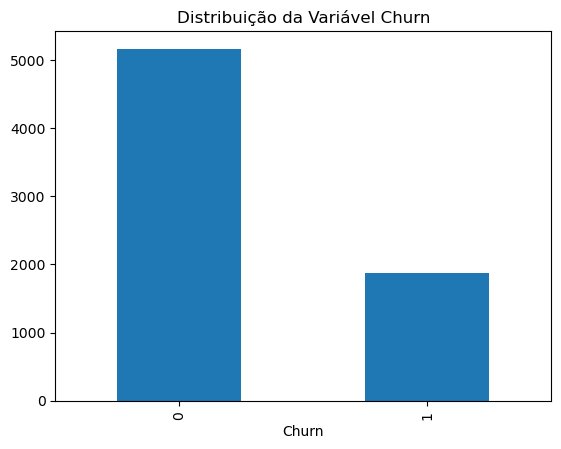

In [8]:
# Conversão da variável Churn para valores binários
dados["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})

# Distribuição da variável alvo
dados["Churn"].value_counts(normalize=True)

dados["Churn"].value_counts().plot(kind="bar")
plt.title("Distribuição da Variável Churn")
plt.show()


### Relação entre Churn e Tempo de Permanência

Esta análise busca verificar se o tempo de permanência do cliente está associado à probabilidade de evasão.

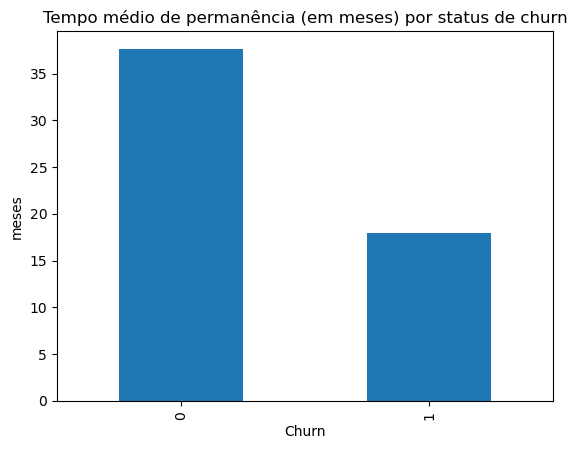

In [9]:
dados.groupby("Churn")["tenure"].mean()
dados.groupby("Churn")["tenure"].mean().plot(kind="bar")
plt.title("Tempo médio de permanência (em meses) por status de churn")
plt.xlabel("Churn")
plt.ylabel("meses")
plt.show()

### Proporção de churn por tipo de contrato

O gráfico apresenta a distribuição proporcional da variável churn em função do tipo de contrato.

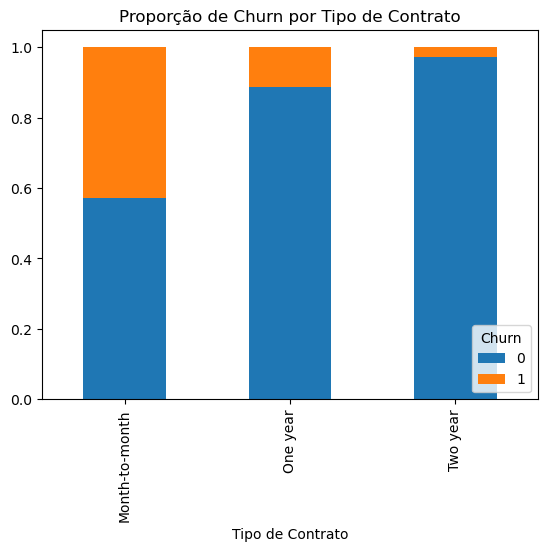

In [10]:
pd.crosstab(dados["Contract"], dados["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proporção de Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.legend(title="Churn", loc="lower right")
plt.show()

### Tempo de permanência (tenure) por status de churn

A variável tenure representa o tempo de permanência do cliente em meses. A análise compara o tempo médio de permanência entre clientes que cancelaram e os que permaneceram ativos.

In [11]:
dados.groupby("Churn")["tenure"].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

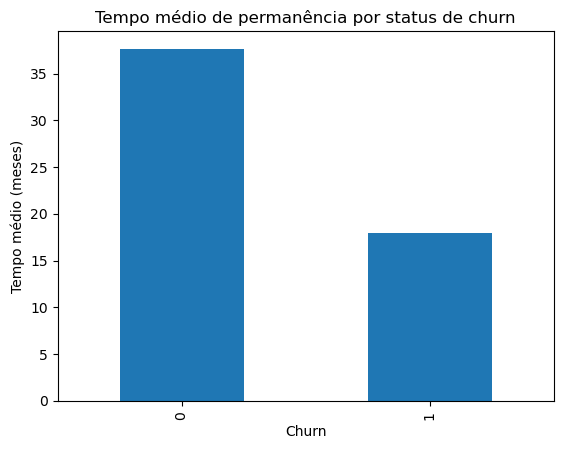

In [12]:
dados.groupby("Churn")["tenure"].mean().plot(kind="bar")
plt.title("Tempo médio de permanência por status de churn")
plt.xlabel("Churn")
plt.ylabel("Tempo médio (meses)")
plt.show()


### Valor médio da mensalidade (MonthlyCharges) por status de churn

A análise compara o valor médio da mensalidade entre clientes que cancelaram e os que permaneceram ativos.

In [13]:
dados.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

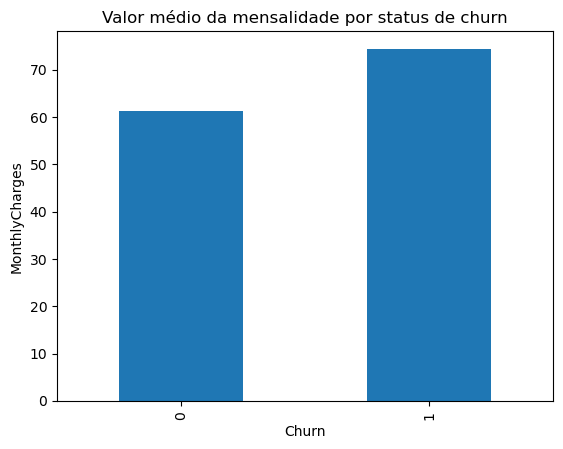

In [14]:

dados.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Valor médio da mensalidade por status de churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()


## Preparação dos Dados para Modelagem

Após a etapa de análise exploratória e identificação dos principais fatores associados ao churn, os dados foram preparados para a aplicação de modelos preditivos. Essa etapa incluiu a separação da variável alvo, o tratamento das variáveis categóricas e numéricas e a divisão do conjunto de dados em bases de treinamento e teste.

### Separação da variável alvo

A variável *Churn* foi definida como variável alvo do modelo, enquanto as demais variáveis foram utilizadas como preditoras. A variável identificadora *customerID* foi removida por não possuir valor preditivo.

In [15]:
# Variável alvo
y = dados["Churn"]

# Variáveis explicativas
X = dados.drop(columns=["Churn", "customerID"])

### Identificação das variáveis categóricas e numéricas

As variáveis foram classificadas em categóricas e numéricas para aplicação de técnicas de pré-processamento adequadas a cada tipo.

In [16]:
# Variáveis categóricas
cat_cols = X.select_dtypes(include="object").columns

# Variáveis numéricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols, num_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

### Codificação das variáveis categóricas

As variáveis categóricas foram transformadas por meio da técnica de *One-Hot Encoding*, permitindo sua utilização em modelos de aprendizado de máquina.

In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)

X_cat = encoder.fit_transform(X[cat_cols])

X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

### Padronização das variáveis numéricas

As variáveis numéricas foram padronizadas para garantir que estivessem na mesma escala, facilitando a convergência e a interpretação dos modelos.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num = scaler.fit_transform(X[num_cols])

X_num = pd.DataFrame(X_num, columns=num_cols)

### Consolidação da base de dados

Após o pré-processamento, as variáveis numéricas e categóricas foram combinadas, resultando no conjunto final de dados utilizado na etapa de modelagem.

In [19]:
X_prepared = pd.concat(
    [X_num.reset_index(drop=True),
     X_cat.reset_index(drop=True)],
    axis=1
)

X_prepared.shape

(7032, 30)

### Divisão dos dados em treino e teste

O conjunto de dados foi dividido em bases de treinamento e teste, preservando a proporção da variável alvo por meio da técnica de estratificação.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [21]:
X_train.shape
y_train.value_counts(normalize=True)

Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

## Modelo Baseline

Com o objetivo de estabelecer uma referência inicial de desempenho, foi treinado um modelo baseline de classificação. Esse modelo permite avaliar se abordagens mais complexas são justificadas nas etapas posteriores do trabalho.

Foi utilizada a Regressão Logística como modelo baseline por sua simplicidade, interpretabilidade e ampla utilização em problemas de classificação binária, especialmente em análises de churn.

In [26]:
from sklearn.linear_model import LogisticRegression

# Instanciando o modelo baseline
modelo_baseline = LogisticRegression(max_iter=1000, random_state=42)

# Treinando o modelo
modelo_baseline.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
# Predições
y_pred = modelo_baseline.predict(X_test)

### Avaliação do desempenho

O desempenho do modelo foi avaliado por meio de métricas adequadas para problemas com desbalanceamento moderado, incluindo acurácia, precisão, recall e F1-score.

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Acurácia
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.8056872037914692

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



### Matriz de confusão

A matriz de confusão foi utilizada para analisar a distribuição dos acertos e erros do modelo, permitindo melhor compreensão do comportamento das predições.

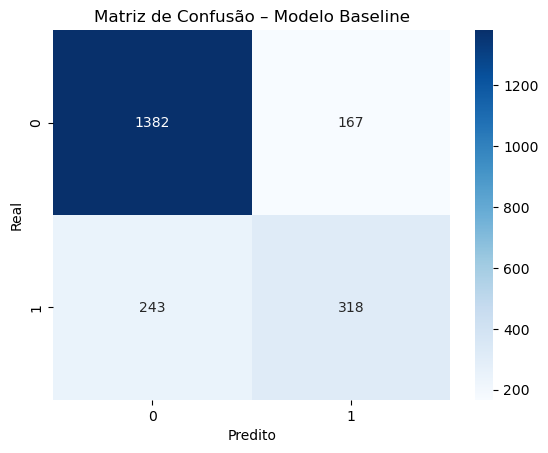

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão – Modelo Baseline")
plt.show()